# Magnetic Fusion Edge Demo

In this demo ...

To get started, let's import the required libraries.

In [1]:
# third party imports
import matplotlib.pyplot as plt
from matplotlib.colors import LogNorm
import numpy as np
import pandas as pd
from pandas import DataFrame as df
from scipy.optimize import fsolve

#twinLab Imports
import twinlab as tl

#set digiLab colors
colors = ["#162448","#009FE3","#7DB928","#FFB500"]


          ====== TwinLab Client Initialisation ======
          Version     : 2.19.0
          User        : dan.greenhouse@digilab.co.uk
          Server      : https://twinlab.digilab.co.uk/v3
          Environment : /Users/danielgreenhouse/Documents/Magnetic-Fusion-Performance/.env



## Set your API Key.

If you don't already have one, please vist https://www.digilab.co.uk/contact. For security, we normally recommend performing this step with a .env file or secrets.

In [2]:
tl.set_user("dan.greenhouse@digilab.co.uk")
tl.set_api_key("tl_zsmry3DwI8vKZ19ggxaN9g")

# Remove this
tl.set_server_url("https://r8py43zvu1.execute-api.eu-west-2.amazonaws.com/stage")

We need to define our edge model

In [3]:

from edge_demo_helper import ion_flux_model, plot_one_d, log_space, random_log_space

This is our sputtering model. It contains parameters upstream temperature and upstream density. It returns the sputtering yield. It has additional hyperparameters which can provide improved model complexity. 

Let's start making some data with it

In [4]:
upstream_q_range = (1.e4, 1.e10)
num = 3

df_train = pd.DataFrame(
    {
        "Upstream Heat Flux": log_space(*upstream_q_range, num),
    }
)

# Let's use our model to predict the ion flux
df_train['Ion Flux'] = df_train.apply(ion_flux_model, axis=1)

df_train['log(Upstream Heat Flux)'] = df_train["Upstream Heat Flux"].apply(np.log)
df_train['log(Ion Flux)'] = df_train["Ion Flux"].apply(np.log)
# Let's view the results
display(df_train)


,Upstream Heat Flux,Ion Flux,log(Upstream Heat Flux),log(Ion Flux)
0,1.000000e+04,1.206752e+24,9.210340,55.449974
1,1.000000e+07,2.516336e+23,16.118096,53.882261
2,1.000000e+10,2.472887e+24,23.025851,56.167428


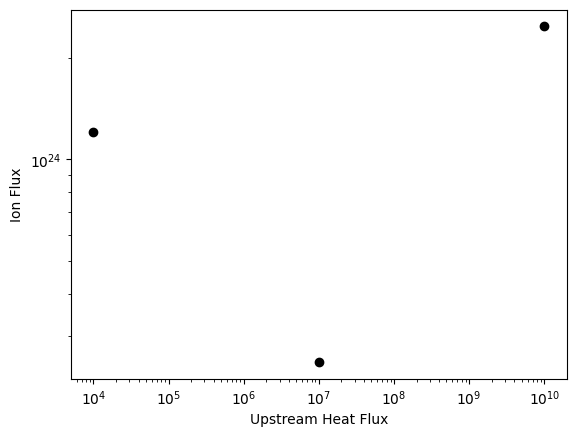

In [5]:

x_quantity = "Upstream Heat Flux"
y_quantity = "Ion Flux"
plot_one_d(train_df=df_train,
           x_quantity_name=x_quantity,
           y_quantity_name=y_quantity
                            )

Now we have some data points from our model, let's add it to twinLab

In [6]:
# Define the name of the dataset
model_dataset_id = "Model_Data"

# Initialise a Dataset object
# model_dataset.delete()
model_dataset = tl.Dataset(id=model_dataset_id)

# Upload the dataset to the cloud
model_dataset.upload(df_train)

Exception: Error Code: 400 - Dataset 'Model_Data' already exists. Rename your dataset or use `Dataset.delete` to proceed.

We can now make an emulator with our data set

In [ ]:
# Initialise emulator
model_emulator_id = "Model_GP"
# model_emulator.delete()
model_emulator = tl.Emulator(id=model_emulator_id)

# Train the emulator
model_emulator.train(dataset=model_dataset,
                     inputs=["log(Upstream Heat Flux)"],
                     outputs=["Ion Flux"],
                     verbose=True)

We have made a surrogate model! Now we can test it out

In [ ]:
# Let's make an array of input points
nmesh = 100
df_test = pd.DataFrame(
    {
        "Upstream Heat Flux": log_space(*upstream_q_range, nmesh),
    }
)     
df_test['log(Upstream Heat Flux)'] = df_test["Upstream Heat Flux"].apply(np.log)

# We will use our surrogate model to predict with this
model_predictions = model_emulator.predict(df_test[["log(Upstream Heat Flux)"]])

df_test["Ion Flux"] = model_predictions[0]
df_test["Ion Flux Standard Deviation"] = model_predictions[1]


In [ ]:

# df_test['Ion Flux'] = df_test["log(Ion Flux)"].apply(np.exp)
# df_test['Ion Flux Standard Deviation'] = df_test["log(Ion Flux Standard Deviation)"].apply(np.exp)
x_quantity = "Upstream Heat Flux"
y_quantity = "Ion Flux"
plot_one_d(train_df=df_train,
           x_quantity_name=x_quantity,
           y_quantity_name=y_quantity,
           prediction_df=df_test,
           y_quantity_std_name="Ion Flux Standard Deviation"
                            )

We have our surrogate model, but we can see that our uncertainty is very large!

In [ ]:

df_suggested_train, _ = model_emulator.recommend(num_points=2,
                                        acq_func="explore"
                                        # acq_func="ExpectedImprovement"
                                        )


Let's evaluate our model at these suggested points

In [ ]:

df_suggested_train['Upstream Heat Flux'] = df_suggested_train["log(Upstream Heat Flux)"].apply(np.exp)
display(df_suggested_train)
# Let's use our model to predict the ion flux
df_suggested_train['Ion Flux'] = df_suggested_train['Upstream Heat Flux'].apply(ion_flux_model)


df_increased_train = pd.concat((df_train, df_suggested_train))


# df_suggested_train['log(Upstream Heat Flux)'] = df_suggested_train["Upstream Heat Flux"].apply(np.log, axis=1)
# df_suggested_train['log(Ion Flux)'] = df_suggested_train["Ion Flux"].apply(np.log, axis=1)
display(df_suggested_train)

In [ ]:

plot_one_d(train_df=df_increased_train,
           x_quantity_name=x_quantity,
           y_quantity_name=y_quantity,
        #    prediction_df=df_test,
        #    y_quantity_std_name="Ion Flux Standard Deviation"
                            )

Now let's train an improved emulator with this increased data set

In [ ]:
# Define the name of the dataset
model_dataset_increased_id = "Model_Data_Increased"
model_dataset_increased.delete()
# Initialise a Dataset object
model_dataset_increased = tl.Dataset(id=model_dataset_increased_id)

# Upload the dataset to the cloud
model_dataset_increased.upload(df_increased_train)

In [ ]:
# Initialise emulator
model_increased_emulator_id = "Model_Increased_GP"
# model_increased_emulator.delete()
model_increased_emulator = tl.Emulator(id=model_increased_emulator_id)

# Train the emulator
model_increased_emulator.train(dataset=model_dataset_increased,
                     inputs=["log(Upstream Heat Flux)"],
                     outputs=["Ion Flux"],
                     verbose=True)

Now let's try the predictions with our improved data set

In [ ]:
# Let's make an array of input points
nmesh = 100
df_increased_test = pd.DataFrame(
    {
        "Upstream Heat Flux": log_space(*upstream_q_range, nmesh),
    }
)
df_increased_test['log(Upstream Heat Flux)'] = df_increased_test["Upstream Heat Flux"].apply(np.log)

# We will use our surrogate model to predict with this
model_increased_predictions = model_increased_emulator.predict(df_test[["log(Upstream Heat Flux)"]])

df_increased_test["Ion Flux"] = model_increased_predictions[0]
df_increased_test["Ion Flux Standard Deviation"] = model_increased_predictions[1]


In [ ]:

plot_one_d(train_df=df_increased_train,
           x_quantity_name=x_quantity,
           y_quantity_name=y_quantity,
           prediction_df=df_increased_test,
           y_quantity_std_name="Ion Flux Standard Deviation"
                            )

Let's try again!

In [ ]:
def training_loop(train_df,
                  emulator,
                  model,
                  model_dataset,
                  num_points=1):
    print(type(emulator))
    df_suggested_train, _ = emulator.recommend(num_points=num_points,
                                            acq_func="explore"
                                            # acq_func="ExpectedImprovement"
                                            )
    df_suggested_train['Upstream Heat Flux'] = df_suggested_train["log(Upstream Heat Flux)"].apply(np.exp)
    # display(df_suggested_train)
    # Let's use our model to predict the ion flux
    df_suggested_train['Ion Flux'] = df_suggested_train['Upstream Heat Flux'].apply(model)


    df_increased_train = pd.concat((train_df, df_suggested_train))
    
    # display(df_suggested_train)
    # Define the name of the dataset
    model_dataset_increased_id = "Model_Data_Increased"
    model_dataset.delete()
    # Initialise a Dataset object
    model_dataset = tl.Dataset(id=model_dataset_increased_id)

    # Upload the dataset to the cloud
    model_dataset.upload(df_increased_train)

    # Re train with this new data set

    emulator.delete()
    # Initialise emulator
    increased_emulator_id = "Model_Increased_GP"
    # model_increased_emulator.delete()
    increased_emulator = tl.Emulator(id=increased_emulator_id)

    # Train the emulator
    increased_emulator.train(dataset=model_dataset,
                        inputs=["log(Upstream Heat Flux)"],
                        outputs=["Ion Flux"],
                        verbose=True)
    
    model_increased_predictions = increased_emulator.predict(df_test[["log(Upstream Heat Flux)"]])
    df_increased_test["Ion Flux"] = model_increased_predictions[0]
    df_increased_test["Ion Flux Standard Deviation"] = model_increased_predictions[1]
    plot_one_d(train_df=df_increased_train,
            x_quantity_name=x_quantity,
            y_quantity_name=y_quantity,
            prediction_df=df_increased_test,
            y_quantity_std_name="Ion Flux Standard Deviation"
                                )
    return increased_emulator, df_increased_train, model_dataset


for i in range(3):
    emulator, df_increased_train, model_dataset = training_loop(
                df_increased_train,
                emulator,
                model_dataset=model_dataset_increased,
                model=ion_flux_model)

In [ ]:
model_increased_emulator
model_increased_predictions = model_increased_emulator.predict(df_test[["log(Upstream Heat Flux)"]])
df_increased_test["Ion Flux"] = model_increased_predictions[0]
df_increased_test["Ion Flux Standard Deviation"] = model_increased_predictions[1]
plot_one_d(train_df=df_increased_train,
           x_quantity_name=x_quantity,
           y_quantity_name=y_quantity,
           prediction_df=df_increased_test,
           y_quantity_std_name="Ion Flux Standard Deviation"
                            )

In [ ]:


df_increased_test["Ion Flux"] = model_increased_predictions[0]
df_increased_test["Ion Flux Standard Deviation"] = model_increased_predictions[1]
plot_one_d(train_df=df_increased_train,
           x_quantity_name=x_quantity,
           y_quantity_name=y_quantity,
           prediction_df=df_increased_test,
           y_quantity_std_name="Ion Flux Standard Deviation"
                            )

In [ ]:
model_dataset.delete()
model_emulator.delete()

Finally, we will tidy up our folder

In [ ]:
# Delete emulator and dataset
# simple_model_emulator.delete()
simple_model_dataset.delete()
improved_emulator.delete()
improved_dataset.delete()

We can see there's a rough positive correlation between the two; as magnetic field increases, so does energy confinement time. However, they are not perfectly correlated and the relationship seems very unclear and messy. This is because there are more than 7 other important parameters changing across these experiments, so of course it's difficult to see a clear relationship when only 1 of the features is used for plotting.